# Análise Exploratória da Amostra

## Leitura e Armazenamento

In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

base_dir = Path.cwd()
csv_path = base_dir / "amostra.csv"

dados = pd.read_csv(csv_path, decimal=",")
variaveis_numericas = dados.drop(columns=["ID", "Município", "UF"], errors="ignore").select_dtypes(include="number")

## Matriz de Correlação

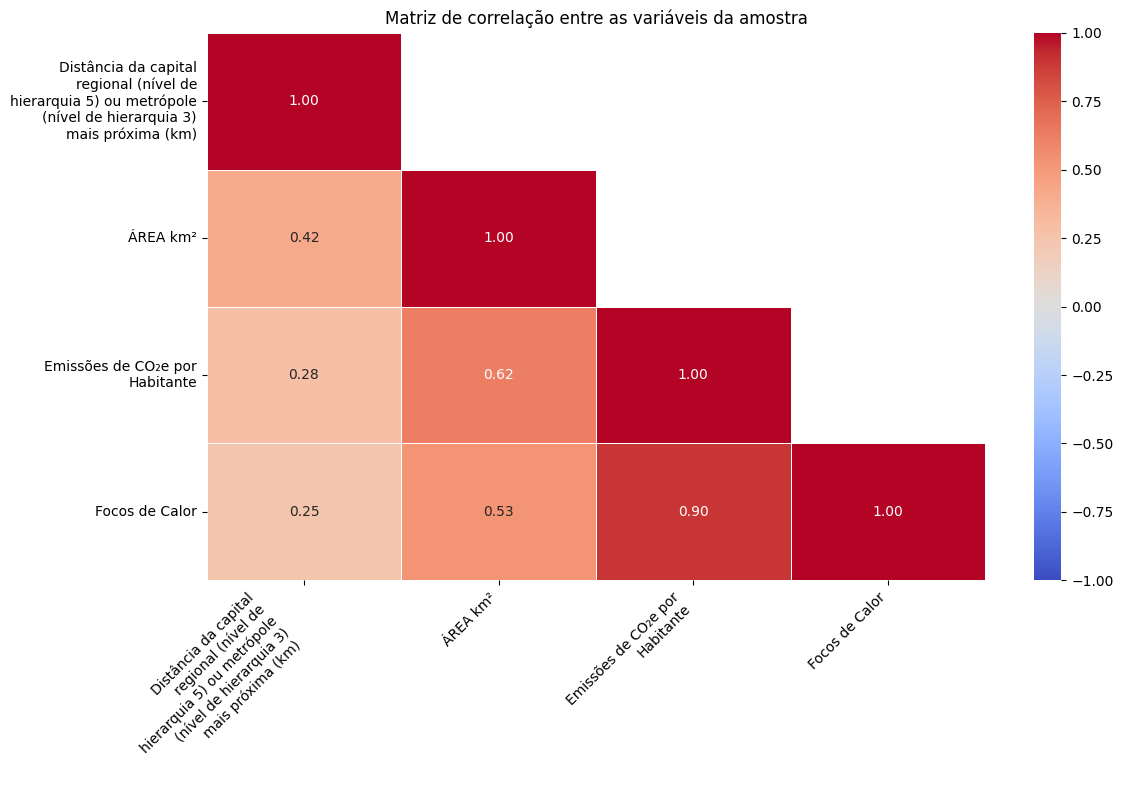

In [2]:
matriz_correlacao = variaveis_numericas.corr()

mask = np.triu(np.ones_like(matriz_correlacao, dtype=bool), k=1)

plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    matriz_correlacao,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
)
ax.set_xticklabels([textwrap.fill(label.get_text(), 28) for label in ax.get_xticklabels()], rotation=45, ha="right")
ax.set_yticklabels([textwrap.fill(label.get_text(), 28) for label in ax.get_yticklabels()], rotation=0)
plt.title("Matriz de correlação entre as variáveis da amostra")
plt.tight_layout()
plt.show()

## Alfa de Cronbach Padronizado

### Sem cada uma das variáveis

In [3]:
def alfa_cronbach_padronizado(correlacoes: pd.DataFrame) -> float:
    k = correlacoes.shape[0]

    soma_total = correlacoes.to_numpy().sum()
    if soma_total == 0:
        raise ValueError("Não foi possível calcular o alfa: a soma total da matriz de correlação é zero.")

    return float((k / (k - 1)) * (1 - (k / soma_total)))


alfa_sem_cada_variavel = {}

for variavel in variaveis_numericas.columns:
    subset = variaveis_numericas.drop(columns=[variavel]).dropna()
    alfa_sem_cada_variavel[variavel] = alfa_cronbach_padronizado(subset.corr())

print("Alfa de Cronbach padronizado sem cada variável:")
for variavel, alfa in alfa_sem_cada_variavel.items():
    print(f"- Sem '{variavel}': {alfa:.2f}")

Alfa de Cronbach padronizado sem cada variável:
- Sem 'Distância da capital regional (nível de hierarquia 5) ou metrópole (nível de hierarquia 3)  mais próxima (km)': 0.86
- Sem 'ÁREA km²': 0.73
- Sem 'Emissões de CO₂e por Habitante': 0.66
- Sem 'Focos de Calor': 0.70


### Do dataset inteiro

In [4]:
alfa_total = alfa_cronbach_padronizado(variaveis_numericas.dropna().corr())

print("Alfa de Cronbach padronizado do dataset inteiro:")
print(f"{alfa_total:.2f}")

Alfa de Cronbach padronizado do dataset inteiro:
0.80
